# Integrates the best detection model (YOLO26m-det) and the best segmentation model (YOLO26s-seg) via a calibrated centroid→overlap geometric-association procedure. Generates article Table 16 (timing), Table 17 (global accuracy/coverage), Table 18 (per-category accuracy), and the six-panel qualitative figure (Section 3.6).

This notebook combines the two best models obtained so far:

- **Cavity detection:** `modelo_deteccion_final.pt`
- **Dental instance segmentation:** `yolo26s_dientes_best.pt`

It addresses the outstanding items listed in the article for Phase 4 (2.4.3), Phase 5 (2.5, 3.5.2 detector confusion matrix, 3.5.3 Table 16, 3.5.4 Tables 17 and 18), and Phase 6 (3.6, six-panel figure). It follows the same cell structure as the segmentation and detection pipelines already used.

⚠️ **Important:** The caries detection dataset (`DATASET CARIES`) and the dental segmentation dataset (`DATASET DIENTES`) are separate image collections. To geometrically associate a caries bounding box with a dental mask, both models must be run **on the same images**. This pipeline uses images from the caries detection dataset (which do have caries annotations) as its basis and applies the segmentation model to them to generate the necessary masks. If you have an additional dataset with both reference annotations, replace the image source in CELL 2.

## CELL 0 — Mount Drive and Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sklearn
print(sklearn.__version__)
# sklearn version check (needed for cohen_kappa_score / GroupShuffleSplit compatibility)

!pip install -q ultralytics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## CELL 1 — Load the two best models

In [ ]:
from pathlib import Path
from ultralytics import YOLO

RUTA_MODELO_DET = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO CARIES/modelo_deteccion_final.pt")
RUTA_MODELO_SEG = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO DIENTES/yolo26s_dientes_best.pt")

assert RUTA_MODELO_DET.exists(), f"No se encontró {RUTA_MODELO_DET}"
assert RUTA_MODELO_SEG.exists(), f"No se encontró {RUTA_MODELO_SEG}"

modelo_det = YOLO(str(RUTA_MODELO_DET))   # YOLO26m-det — detección de caries (clase única "Caries")
modelo_seg = YOLO(str(RUTA_MODELO_SEG))   # YOLO26s-seg  — segmentación de instancias dentales (8 clases)

NOMBRES_DIENTES = ['1st Molar', '1st Premolar', '2nd Molar', '2nd Premolar',
                    '3rd Molar', 'Canine', 'Central Incisor', 'Lateral Incisor']

print("✅ Modelo de detección cargado:", RUTA_MODELO_DET.name)
print("✅ Modelo de segmentación cargado:", RUTA_MODELO_SEG.name)

✅ Modelo de detección cargado: modelo_deteccion_final.pt
✅ Modelo de segmentación cargado: yolo26s_dientes_best.pt


### Quick sanity check — false-positive rate on native vs external negative images" y márcala como diagnóstica, no parte del flujo principal.

In [ ]:
from pathlib import Path

CARIES_ROOT = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3")

paths_ahmed_neg = []
paths_chaudhary_neg = []

for split in ["train", "val", "test"]:
    img_dir = CARIES_ROOT / "images" / split
    lbl_dir = CARIES_ROOT / "labels" / split
    for img_p in img_dir.glob("*.*"):
        lbl_p = lbl_dir / f"{img_p.stem}.txt"
        es_negativa = lbl_p.exists() and lbl_p.stat().st_size == 0
        if not es_negativa:
            continue
        if img_p.name.startswith("healthy_"):
            paths_chaudhary_neg.append(img_p)
        else:
            paths_ahmed_neg.append(img_p)

print(f"Negativas Ahmed encontradas: {len(paths_ahmed_neg)} (esperado 26)")
print(f"Negativas Chaudhary encontradas: {len(paths_chaudhary_neg)} (esperado 197)")

resultados_ahmed_neg = modelo_det.predict(source=[str(p) for p in paths_ahmed_neg], conf=0.25, verbose=False)
resultados_chaud_neg = modelo_det.predict(source=[str(p) for p in paths_chaudhary_neg], conf=0.25, verbose=False)

fp_ahmed = sum(1 for r in resultados_ahmed_neg if len(r.boxes) > 0)
fp_chaudhary = sum(1 for r in resultados_chaud_neg if len(r.boxes) > 0)

print(f"FP en negativos Ahmed: {fp_ahmed}/{len(resultados_ahmed_neg)} = {100*fp_ahmed/len(resultados_ahmed_neg):.1f}%")
print(f"FP en negativos Chaudhary: {fp_chaudhary}/{len(resultados_chaud_neg)} = {100*fp_chaudhary/len(resultados_chaud_neg):.1f}%")


Negativas Ahmed encontradas: 36 (esperado 26)
Negativas Chaudhary encontradas: 219 (esperado 197)
FP en negativos Ahmed: 11/36 = 30.6%
FP en negativos Chaudhary: 2/219 = 0.9%


## CELL 2 — Define the set of images to be evaluated

The caries detection dataset (`DATASET CARIES`) is used as the basis, since it contains reference annotations (caries boxes). The pre-defined partitions are reused: validation for calibrating τ and δ, and testing for the final evaluation.

In [ ]:
from pathlib import Path
import pandas as pd

# --- Rutas base ---
DATASET_CARIES = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3")

IMG_CALIBRACION = sorted((DATASET_CARIES / "images" / "val").glob("*"))
LBL_CALIBRACION = DATASET_CARIES / "labels" / "val"

IMG_PRUEBA = sorted((DATASET_CARIES / "images" / "test").glob("*"))
LBL_PRUEBA = DATASET_CARIES / "labels" / "test"

RUTA_CSV_CALIBRACION = DATASET_CARIES.parent / "calibracion_asociacion_geometrica.csv"
RUTA_CSV_PRUEBA = DATASET_CARIES.parent / "referencia_asociacion_prueba.csv"
RUTA_GRID = DATASET_CARIES.parent / "grid_tau_delta.csv"

print(f"Imágenes de calibración (validación): {len(IMG_CALIBRACION)}")
print(f"Imágenes de evaluación final (prueba): {len(IMG_PRUEBA)}")

# --- Verificar que los CSV de referencia existen y cuánto llevas ---
for nombre, ruta in [("Calibración", RUTA_CSV_CALIBRACION), ("Prueba", RUTA_CSV_PRUEBA)]:
    if ruta.exists():
        df_tmp = pd.read_csv(ruta, dtype=str)
        completas = (df_tmp['consenso'].notna() & (df_tmp['consenso'].astype(str).str.strip() != '')).sum()
        print(f"✅ {nombre}: {completas}/{len(df_tmp)} filas con consenso.")
    else:
        print(f"❌ {nombre}: no encontrado en {ruta}")

# --- Recuperar TAU_FINAL y DELTA_FINAL desde el grid ya calculado (sin rehacer el barrido) ---
if RUTA_GRID.exists():
    df_grid = pd.read_csv(RUTA_GRID).sort_values('media_armonica', ascending=False)
    TAU_FINAL = float(df_grid.iloc[0]['tau'])
    DELTA_FINAL = float(df_grid.iloc[0]['delta'])
    print(f"\n🏆 Recuperado del grid: τ = {TAU_FINAL}, δ = {DELTA_FINAL} "
          f"(media armónica = {df_grid.iloc[0]['media_armonica']:.4f})")
else:
    print(f"\n❌ No se encontró {RUTA_GRID} — necesitas correr la Celda 6 (barrido de τ y δ) primero.")

Imágenes de calibración (validación): 242
Imágenes de evaluación final (prueba): 242
✅ Calibración: 40/40 filas con consenso.
✅ Prueba: 777/777 filas con consenso.

🏆 Recuperado del grid: τ = 0.1, δ = 0.02 (media armónica = 0.9747)


### CELL 2B — Check whether the consensus that has already been reached still applies

In [ ]:
import pandas as pd

nombres_val_actuales = {r.name for r in IMG_CALIBRACION}
nombres_test_actuales = {r.name for r in IMG_PRUEBA}

if RUTA_CSV_CALIBRACION.exists():
    df_cal_vieja = pd.read_csv(RUTA_CSV_CALIBRACION, dtype=str)
    nombres_en_csv_cal = set(df_cal_vieja['imagen'].unique())
    coinciden_cal = nombres_en_csv_cal & nombres_val_actuales
    print(f"CALIBRACIÓN: {len(nombres_en_csv_cal)} imágenes en el CSV viejo, "
          f"{len(coinciden_cal)} siguen existiendo en val actual "
          f"({len(coinciden_cal)/len(nombres_en_csv_cal):.1%} de coincidencia)")
else:
    print("No existe CSV de calibración previo.")

if RUTA_CSV_PRUEBA.exists():
    df_prueba_vieja = pd.read_csv(RUTA_CSV_PRUEBA, dtype=str)
    nombres_en_csv_prueba = set(df_prueba_vieja['imagen'].unique())
    coinciden_prueba = nombres_en_csv_prueba & nombres_test_actuales
    print(f"PRUEBA: {len(nombres_en_csv_prueba)} imágenes en el CSV viejo, "
          f"{len(coinciden_prueba)} siguen existiendo en test actual "
          f"({len(coinciden_prueba)/len(nombres_en_csv_prueba):.1%} de coincidencia)")
else:
    print("No existe CSV de prueba previo.")

CALIBRACIÓN: 38 imágenes en el CSV viejo, 38 siguen existiendo en val actual (100.0% de coincidencia)
PRUEBA: 199 imágenes en el CSV viejo, 199 siguen existiendo en test actual (100.0% de coincidencia)


## CELL 3 — Joint inference functions (detection + segmentation) per image

In [ ]:
import numpy as np
import cv2

def inferir_par(ruta_imagen, conf_det=0.25, conf_seg=0.25):
    """
    Ejecuta ambos modelos sobre la misma imagen y devuelve:
    - lista de cajas de caries: [{'bbox': (x1,y1,x2,y2), 'conf': float}, ...]
    - lista de instancias dentales: [{'clase': str, 'mask': np.ndarray bool (H,W), 'conf': float}, ...]
    """
    img = cv2.imread(str(ruta_imagen))
    h, w = img.shape[:2]

    res_det = modelo_det.predict(source=str(ruta_imagen), conf=conf_det, verbose=False)[0]
    cajas = []
    if res_det.boxes is not None:
        for box, conf in zip(res_det.boxes.xyxy.cpu().numpy(), res_det.boxes.conf.cpu().numpy()):
            cajas.append({'bbox': tuple(box), 'conf': float(conf)})

    res_seg = modelo_seg.predict(source=str(ruta_imagen), conf=conf_seg, verbose=False)[0]
    instancias = []
    if res_seg.masks is not None:
        masks_resized = res_seg.masks.data.cpu().numpy()  # (N, mh, mw) en resolución del modelo
        clases = res_seg.boxes.cls.cpu().numpy().astype(int)
        confs = res_seg.boxes.conf.cpu().numpy()
        for m, c, conf in zip(masks_resized, clases, confs):
            m_full = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
            instancias.append({'clase': NOMBRES_DIENTES[c], 'mask': m_full, 'conf': float(conf)})

    return cajas, instancias, (h, w)

print("✅ Función de inferencia conjunta definida")

✅ Función de inferencia conjunta definida


## CELL 4 — Geometric association procedure (centroid → overlap, with τ and δ)

This implements exactly the procedure described in section 2.4.3 of the article: first, the centroid of the box is tested; if it does not fall within a single mask, the overlap ratio *Sᵢⱼ = area(Bᵢ ∩ Mⱼ) / area(Bᵢ)* is used, accepting the assignment only if the best score exceeds τ and the difference from the second-best score exceeds δ.

In [ ]:
def bbox_a_mascara(bbox, shape):
    x1, y1, x2, y2 = [int(round(v)) for v in bbox]
    h, w = shape
    x1, x2 = max(0, x1), min(w, x2)
    y1, y2 = max(0, y1), min(h, y2)
    m = np.zeros((h, w), dtype=bool)
    m[y1:y2, x1:x2] = True
    return m

def centroide(bbox):
    x1, y1, x2, y2 = bbox
    return (int(round((x1 + x2) / 2)), int(round((y1 + y2) / 2)))

def asociar_detecciones(cajas, instancias, shape, tau, delta):
    """
    Devuelve una lista de resultados por caja de caries:
    {'bbox':..., 'estado': 'asociada'|'no_asociada'|'ambigua',
     'instancia_idx': int|None, 'clase_asignada': str|None, 'score': float|None}
    """
    resultados = []
    for caja in cajas:
        bbox = caja['bbox']
        cx, cy = centroide(bbox)

        contenido_en = [i for i, inst in enumerate(instancias) if inst['mask'][cy, cx]]

        if len(contenido_en) == 1:
            idx = contenido_en[0]
            resultados.append({'bbox': bbox, 'estado': 'asociada', 'instancia_idx': idx,
                                'clase_asignada': instancias[idx]['clase'], 'score': 1.0,
                                'metodo': 'centroide'})
            continue

        # Centroide fuera de toda máscara, o dentro de más de una: usar razón de solapamiento
        box_mask = bbox_a_mascara(bbox, shape)
        area_bi = box_mask.sum()
        scores = []
        for i, inst in enumerate(instancias):
            inter = np.logical_and(box_mask, inst['mask']).sum()
            s_ij = inter / area_bi if area_bi > 0 else 0.0
            scores.append((i, s_ij))
        scores.sort(key=lambda t: t[1], reverse=True)

        if not scores or scores[0][1] < tau:
            resultados.append({'bbox': bbox, 'estado': 'no_asociada', 'instancia_idx': None,
                                'clase_asignada': None, 'score': scores[0][1] if scores else 0.0,
                                'metodo': 'solapamiento'})
            continue

        mejor_idx, mejor_score = scores[0]
        segundo_score = scores[1][1] if len(scores) > 1 else 0.0
        if (mejor_score - segundo_score) <= delta:
            resultados.append({'bbox': bbox, 'estado': 'ambigua', 'instancia_idx': None,
                                'clase_asignada': None, 'score': mejor_score,
                                'metodo': 'solapamiento'})
        else:
            resultados.append({'bbox': bbox, 'estado': 'asociada', 'instancia_idx': mejor_idx,
                                'clase_asignada': instancias[mejor_idx]['clase'], 'score': mejor_score,
                                'metodo': 'solapamiento'})
    return resultados

print("✅ Procedimiento de asociación geométrica definido")

✅ Procedimiento de asociación geométrica definido


In [ ]:
cache_prueba = {}
for ruta in IMG_PRUEBA:
    cajas, instancias, shape = inferir_par(ruta)
    cache_prueba[ruta.name] = (cajas, instancias, shape)




---



---



---



## Manual double-review procedure (one-time; already completed — outputs saved to CSV).
Re-running these cells will attempt a fresh review; skip to Cell 6 / Cell 8 if you already have the consensus CSVs.

## CELL 5 — Generate Manual Reference Template (Calibration)

Before calibrating τ and δ, a human reference is required: for each caries box in the calibration subset, which dental instance is the correct one. This cell generates the CSV file that two reviewers must complete independently (column `correct_instance_reviewer1/2`), in accordance with the procedure described in 2.5. Discrepancies are resolved by consensus before proceeding to CELL 6.



---



---



---



In [ ]:
import pandas as pd
import random

random.seed(42)
N_MUESTRA_CALIBRACION = 40

filas = []
for ruta in IMG_CALIBRACION:
    cajas, instancias, shape = inferir_par(ruta)
    for j, caja in enumerate(cajas):
        filas.append({
            'imagen': ruta.name,
            'caja_idx': j,
            'bbox_x1': caja['bbox'][0], 'bbox_y1': caja['bbox'][1],
            'bbox_x2': caja['bbox'][2], 'bbox_y2': caja['bbox'][3],
            'conf_deteccion': caja['conf'],
            'n_instancias_candidatas': len(instancias),
            'instancia_correcta_revisor1': '',
            'instancia_correcta_revisor2': '',
            'consenso': '',
        })

df_calibracion = pd.DataFrame(filas)
if len(df_calibracion) > N_MUESTRA_CALIBRACION:
    df_calibracion = df_calibracion.sample(N_MUESTRA_CALIBRACION, random_state=42).reset_index(drop=True)

RUTA_CSV_CALIBRACION = DATASET_CARIES.parent / "calibracion_asociacion_geometrica.csv"
df_calibracion.to_csv(RUTA_CSV_CALIBRACION, index=False)
print(f"📄 Plantilla generada con {len(df_calibracion)} detecciones a revisar: {RUTA_CSV_CALIBRACION}")
print("➡️ Complétala manualmente (dos revisores) antes de continuar con la CELDA 6.")

📄 Plantilla generada con 40 detecciones a revisar: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/calibracion_asociacion_geometrica.csv
➡️ Complétala manualmente (dos revisores) antes de continuar con la CELDA 6.


In [ ]:
from pathlib import Path
import pandas as pd

# Reconstruir solo las rutas (sin regenerar los CSV)
RUTA_CSV_CALIBRACION = DATASET_CARIES.parent / "calibracion_asociacion_geometrica.csv"
RUTA_CSV_PRUEBA = DATASET_CARIES.parent / "referencia_asociacion_prueba.csv"

# Verificar que existen y cuánto llevas avanzado
for nombre, ruta in [("Calibración", RUTA_CSV_CALIBRACION), ("Prueba", RUTA_CSV_PRUEBA)]:
    if ruta.exists():
        df_tmp = pd.read_csv(ruta, dtype=str)
        completas = (df_tmp['consenso'].notna() & (df_tmp['consenso'].astype(str).str.strip() != '')).sum()
        print(f"✅ {nombre}: {ruta.name} encontrado — {completas}/{len(df_tmp)} filas con consenso.")
    else:
        print(f"❌ {nombre}: no se encontró {ruta} — revisa la ruta o si aún no la generaste.")

✅ Calibración: calibracion_asociacion_geometrica.csv encontrado — 0/40 filas con consenso.
❌ Prueba: no se encontró /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/referencia_asociacion_prueba.csv — revisa la ruta o si aún no la generaste.


### CELL 5B (combined) — Simultaneous review by reviewer 1 and reviewer 2

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

df_calibracion = pd.read_csv(RUTA_CSV_CALIBRACION, dtype=str)
cache_revision = {}

def mostrar_figura(idx_fila):
    fila = df_calibracion.iloc[idx_fila]
    ruta = next(r for r in IMG_CALIBRACION if r.name == fila['imagen'])
    if fila['imagen'] not in cache_revision:
        cache_revision[fila['imagen']] = inferir_par(ruta)
    cajas, instancias, shape = cache_revision[fila['imagen']]

    img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
    overlay = img.copy()
    colores = plt.cm.tab20(np.linspace(0, 1, max(len(instancias), 1)))
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, inst in enumerate(instancias):
        color = (colores[i][:3] * 255).astype(np.uint8)
        overlay[inst['mask']] = (0.5 * overlay[inst['mask']] + 0.5 * color).astype(np.uint8)
    ax.imshow(overlay)
    for i, inst in enumerate(instancias):
        ys, xs = np.where(inst['mask'])
        if len(xs) == 0:
            continue
        cx, cy = int(xs.mean()), int(ys.mean())
        ax.text(cx, cy, str(i), color='white', fontsize=13, fontweight='bold',
                ha='center', va='center', bbox=dict(facecolor='black', alpha=0.6, pad=1))
    j = int(fila['caja_idx'])
    x1, y1, x2, y2 = cajas[j]['bbox']
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=3,
                                    edgecolor='red', facecolor='none'))
    ax.set_title(f"Fila {idx_fila}/{len(df_calibracion)} | {fila['imagen']} | caja_idx={j} | instancias 0-{len(instancias)-1}",
                 fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

idx_actual = [0]
while (idx_actual[0] < len(df_calibracion)
       and pd.notna(df_calibracion.at[idx_actual[0], 'instancia_correcta_revisor1'])
       and str(df_calibracion.at[idx_actual[0], 'instancia_correcta_revisor1']).strip() != ''
       and pd.notna(df_calibracion.at[idx_actual[0], 'instancia_correcta_revisor2'])
       and str(df_calibracion.at[idx_actual[0], 'instancia_correcta_revisor2']).strip() != ''):
    idx_actual[0] += 1

texto_r1 = widgets.Text(description='Revisor 1:', placeholder="número o 'ninguna'")
texto_r2 = widgets.Text(description='Revisor 2:', placeholder="número o 'ninguna'")
boton = widgets.Button(description='Guardar y siguiente')
panel = widgets.Output()

def refrescar_panel():
    with panel:
        clear_output(wait=True)
        if idx_actual[0] >= len(df_calibracion):
            print("✅ Revisión completada (ambos revisores). CSV guardado.")
            return
        mostrar_figura(idx_actual[0])
        display(widgets.HBox([texto_r1, texto_r2, boton]))

def al_hacer_clic(b):
    r1 = texto_r1.value.strip()
    r2 = texto_r2.value.strip()
    if r1 == '' or r2 == '':
        return  # exige que ambos respondan antes de avanzar
    df_calibracion.at[idx_actual[0], 'instancia_correcta_revisor1'] = r1
    df_calibracion.at[idx_actual[0], 'instancia_correcta_revisor2'] = r2
    df_calibracion.to_csv(RUTA_CSV_CALIBRACION, index=False)
    idx_actual[0] += 1
    texto_r1.value = ''
    texto_r2.value = ''
    refrescar_panel()

boton.on_click(al_hacer_clic)
texto_r2.on_submit(lambda w: al_hacer_clic(None))

display(panel)
refrescar_panel()


Output()

## CELL 5C — Auto-fill the consensus where reviewer1 and reviewer2 already agree

Se ejecuto esto después de que los dos investigadores hayan llenado sus columnas por separado para todas las filas.

In [ ]:
df_calibracion = pd.read_csv(RUTA_CSV_CALIBRACION, dtype=str)  # como texto, para no corromper índices

r1 = df_calibracion['instancia_correcta_revisor1'].astype(str).str.strip()
r2 = df_calibracion['instancia_correcta_revisor2'].astype(str).str.strip()

coinciden = r1 == r2
df_calibracion.loc[coinciden, 'consenso'] = r1[coinciden]

n_total = len(df_calibracion)
n_coinciden = coinciden.sum()
n_conflicto = n_total - n_coinciden

print(f"✅ {n_coinciden}/{n_total} filas coincidieron y se autocompletó 'consenso'.")
print(f"⚠️ {n_conflicto} filas en desacuerdo — deben discutirlas y escribir el valor final a mano:")

conflictos = df_calibracion[~coinciden][['imagen', 'caja_idx', 'instancia_correcta_revisor1', 'instancia_correcta_revisor2']]
display(conflictos)

df_calibracion.to_csv(RUTA_CSV_CALIBRACION, index=False)
print(f"\n📄 CSV actualizado (revísalo, resuelve los conflictos marcados arriba y vuelve a correr la Celda 6): {RUTA_CSV_CALIBRACION}")

✅ 40/40 filas coincidieron y se autocompletó 'consenso'.
⚠️ 0 filas en desacuerdo — deben discutirlas y escribir el valor final a mano:


,imagen,caja_idx,instancia_correcta_revisor1,instancia_correcta_revisor2



📄 CSV actualizado (revísalo, resuelve los conflictos marcados arriba y vuelve a correr la Celda 6): /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/calibracion_asociacion_geometrica.csv


## CELL 6 — Sweep of τ and δ over the calibration subset

Requires that `calibracion_asociacion_geometrica.csv` already have the `consenso` column fully populated (index of the correct instance, or `none` if the correct tooth was not segmented). Selects τ and δ by maximizing the harmonic mean between accuracy and coverage, thereby avoiding the selection of a threshold that maximizes accuracy at the expense of associating very few cases.

In [ ]:
df_consenso = pd.read_csv(RUTA_CSV_CALIBRACION)
assert df_consenso['consenso'].notna().all() and (df_consenso['consenso'] != '').all(), \
    "Completa la columna 'consenso' en el CSV de calibración antes de continuar."

VALORES_TAU = np.arange(0.10, 0.55, 0.05)
VALORES_DELTA = np.arange(0.02, 0.22, 0.02)

# Cache de inferencias por imagen para no repetir el cómputo en cada combinación de (tau, delta)
cache_calibracion = {}
for ruta in IMG_CALIBRACION:
    cajas, instancias, shape = inferir_par(ruta)
    cache_calibracion[ruta.name] = (cajas, instancias, shape)

filas_grid = []
for tau in VALORES_TAU:
    for delta in VALORES_DELTA:
        correctas = incorrectas = sin_asociar = ambiguas = 0
        for imagen, grupo in df_consenso.groupby('imagen'):
            cajas, instancias, shape = cache_calibracion[imagen]
            resultados = asociar_detecciones(cajas, instancias, shape, tau, delta)
            for _, fila in grupo.iterrows():
                j = int(fila['caja_idx'])
                if j >= len(resultados):
                    continue
                r = resultados[j]
                ref = fila['consenso']
                if r['estado'] == 'asociada':
                    if ref != 'ninguna' and int(ref) == r['instancia_idx']:
                        correctas += 1
                    else:
                        incorrectas += 1
                elif r['estado'] == 'ambigua':
                    ambiguas += 1
                else:
                    sin_asociar += 1

        total_definitivas = correctas + incorrectas
        total_evaluadas = correctas + incorrectas + sin_asociar + ambiguas
        exactitud = correctas / total_definitivas if total_definitivas > 0 else 0.0
        cobertura = total_definitivas / total_evaluadas if total_evaluadas > 0 else 0.0
        media_armonica = (2 * exactitud * cobertura / (exactitud + cobertura)) if (exactitud + cobertura) > 0 else 0.0

        filas_grid.append({'tau': round(tau, 2), 'delta': round(delta, 2),
                            'exactitud': exactitud, 'cobertura': cobertura,
                            'media_armonica': media_armonica,
                            'correctas': correctas, 'incorrectas': incorrectas,
                            'sin_asociar': sin_asociar, 'ambiguas': ambiguas})

df_grid = pd.DataFrame(filas_grid).sort_values('media_armonica', ascending=False)
print(df_grid.head(10).to_string(index=False))

TAU_FINAL = float(df_grid.iloc[0]['tau'])
DELTA_FINAL = float(df_grid.iloc[0]['delta'])
print(f"\n🏆 Configuración seleccionada: τ = {TAU_FINAL}, δ = {DELTA_FINAL} "
      f"(media armónica = {df_grid.iloc[0]['media_armonica']:.4f})")

RUTA_GRID = DATASET_CARIES.parent / "grid_tau_delta.csv"
df_grid.to_csv(RUTA_GRID, index=False)
print(f"📄 Barrido completo guardado en: {RUTA_GRID}")

 tau  delta  exactitud  cobertura  media_armonica  correctas  incorrectas  sin_asociar  ambiguas
 0.1   0.02   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.04   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.06   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.08   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.10   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.12   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.14   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.16   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.18   0.974359      0.975        0.974679         38            1            0         1
 0.1   0.20   0.974359      0.



---



---



---



---



---



## CELL 7 — Manual reference template for the TEST set (final evaluation)

Same logic as CELL 5, but applied to the complete test set and without adjusting τ or δ once they have been set. This is the reference used to generate Tables 16 and 17 in the article (3.5.4).

In [ ]:
filas_prueba = []
for ruta in IMG_PRUEBA:
    cajas, instancias, shape = inferir_par(ruta)
    for j, caja in enumerate(cajas):
        filas_prueba.append({
            'imagen': ruta.name,
            'caja_idx': j,
            'bbox_x1': caja['bbox'][0], 'bbox_y1': caja['bbox'][1],
            'bbox_x2': caja['bbox'][2], 'bbox_y2': caja['bbox'][3],
            'conf_deteccion': caja['conf'],
            'n_instancias_candidatas': len(instancias),
            'instancia_correcta_revisor1': '',
            'instancia_correcta_revisor2': '',
            'consenso': '',
        })

df_prueba_ref = pd.DataFrame(filas_prueba)
RUTA_CSV_PRUEBA = DATASET_CARIES.parent / "referencia_asociacion_prueba.csv"
df_prueba_ref.to_csv(RUTA_CSV_PRUEBA, index=False)
print(f"📄 Plantilla de referencia para PRUEBA generada con {len(df_prueba_ref)} detecciones: {RUTA_CSV_PRUEBA}")
print("➡️ Complétala manualmente (dos revisores + consenso) antes de continuar con la CELDA 8.")

📄 Plantilla de referencia para PRUEBA generada con 777 detecciones: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/referencia_asociacion_prueba.csv
➡️ Complétala manualmente (dos revisores + consenso) antes de continuar con la CELDA 8.


### CELL 7B (combined) — Simultaneous review by Reviewer 1 and Reviewer 2, TEST set

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
import pandas as pd

df_prueba_ref = pd.read_csv(RUTA_CSV_PRUEBA, dtype=str)
cache_revision_prueba = {}

def mostrar_figura_prueba(idx_fila):
    fila = df_prueba_ref.iloc[idx_fila]
    ruta = next(r for r in IMG_PRUEBA if r.name == fila['imagen'])
    if fila['imagen'] not in cache_revision_prueba:
        cache_revision_prueba[fila['imagen']] = inferir_par(ruta)
    cajas, instancias, shape = cache_revision_prueba[fila['imagen']]

    img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
    overlay = img.copy()
    colores = plt.cm.tab20(np.linspace(0, 1, max(len(instancias), 1)))
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, inst in enumerate(instancias):
        color = (colores[i][:3] * 255).astype(np.uint8)
        overlay[inst['mask']] = (0.5 * overlay[inst['mask']] + 0.5 * color).astype(np.uint8)
    ax.imshow(overlay)
    for i, inst in enumerate(instancias):
        ys, xs = np.where(inst['mask'])
        if len(xs) == 0:
            continue
        cx, cy = int(xs.mean()), int(ys.mean())
        ax.text(cx, cy, str(i), color='white', fontsize=13, fontweight='bold',
                ha='center', va='center', bbox=dict(facecolor='black', alpha=0.6, pad=1))
    j = int(fila['caja_idx'])
    x1, y1, x2, y2 = cajas[j]['bbox']
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=3,
                                    edgecolor='red', facecolor='none'))
    ax.set_title(f"[PRUEBA] Fila {idx_fila}/{len(df_prueba_ref)} | {fila['imagen']} | caja_idx={j} | instancias 0-{len(instancias)-1}",
                 fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

idx_actual_p = [0]
while (idx_actual_p[0] < len(df_prueba_ref)
       and pd.notna(df_prueba_ref.at[idx_actual_p[0], 'instancia_correcta_revisor1'])
       and str(df_prueba_ref.at[idx_actual_p[0], 'instancia_correcta_revisor1']).strip() != ''
       and pd.notna(df_prueba_ref.at[idx_actual_p[0], 'instancia_correcta_revisor2'])
       and str(df_prueba_ref.at[idx_actual_p[0], 'instancia_correcta_revisor2']).strip() != ''):
    idx_actual_p[0] += 1

texto_r1_p = widgets.Text(description='Revisor 1:', placeholder="número o 'ninguna'")
texto_r2_p = widgets.Text(description='Revisor 2:', placeholder="número o 'ninguna'")
boton_p = widgets.Button(description='Guardar y siguiente')
panel_p = widgets.Output()

def refrescar_panel_p():
    with panel_p:
        clear_output(wait=True)
        if idx_actual_p[0] >= len(df_prueba_ref):
            print("✅ Revisión del conjunto de prueba completada (ambos revisores). CSV guardado.")
            return
        mostrar_figura_prueba(idx_actual_p[0])
        display(widgets.HBox([texto_r1_p, texto_r2_p, boton_p]))

def al_hacer_clic_p(b):
    r1 = texto_r1_p.value.strip()
    r2 = texto_r2_p.value.strip()
    if r1 == '' or r2 == '':
        return
    df_prueba_ref.at[idx_actual_p[0], 'instancia_correcta_revisor1'] = r1
    df_prueba_ref.at[idx_actual_p[0], 'instancia_correcta_revisor2'] = r2
    df_prueba_ref.to_csv(RUTA_CSV_PRUEBA, index=False)
    idx_actual_p[0] += 1
    texto_r1_p.value = ''
    texto_r2_p.value = ''
    refrescar_panel_p()

boton_p.on_click(al_hacer_clic_p)
texto_r2_p.on_submit(lambda w: al_hacer_clic_p(None))

display(panel_p)
refrescar_panel_p()

Output()

### CELL 7C — Automatic agreement between reviewer1 and reviewer2 + Cohen's kappa

In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

df_prueba_ref = pd.read_csv(RUTA_CSV_PRUEBA, dtype=str)

r1 = df_prueba_ref['instancia_correcta_revisor1'].astype(str).str.strip()
r2 = df_prueba_ref['instancia_correcta_revisor2'].astype(str).str.strip()

coinciden = r1 == r2
df_prueba_ref.loc[coinciden, 'consenso'] = r1[coinciden]

n_total = len(df_prueba_ref)
n_coinciden = int(coinciden.sum())
n_conflicto = n_total - n_coinciden
acuerdo_pct = n_coinciden / n_total if n_total else 0.0
kappa = cohen_kappa_score(r1, r2)

print(f"✅ Acuerdo inicial entre revisores: {n_coinciden}/{n_total} ({acuerdo_pct:.1%})")
print(f"📊 Cohen's kappa: {kappa:.4f}")
print(f"⚠️ {n_conflicto} filas en desacuerdo — resuélvanlas en conjunto y escriban el valor final en 'consenso':")

conflictos = df_prueba_ref[~coinciden][
    ['imagen', 'caja_idx', 'instancia_correcta_revisor1', 'instancia_correcta_revisor2']
]
display(conflictos)

pd.DataFrame([{
    'n_detecciones': n_total, 'acuerdo_inicial_pct': round(acuerdo_pct, 4),
    'cohen_kappa': round(kappa, 4), 'n_discrepancias': n_conflicto,
}]).to_csv(DATASET_CARIES.parent / "acuerdo_doble_revisor_prueba.csv", index=False)

df_prueba_ref.to_csv(RUTA_CSV_PRUEBA, index=False)
print(f"\n📄 CSV actualizado: {RUTA_CSV_PRUEBA}")
print("➡️ Edita 'consenso' a mano para las filas en conflicto, por ejemplo:")
print("   df_prueba_ref.at[idx, 'consenso'] = 'valor_acordado'  (y vuelve a guardar el CSV)")
print("   antes de continuar con la normalización de 'ninguna' y la CELDA 8.")

✅ Acuerdo inicial entre revisores: 714/777 (91.9%)
📊 Cohen's kappa: 0.9110
⚠️ 63 filas en desacuerdo — resuélvanlas en conjunto y escriban el valor final en 'consenso':


,imagen,caja_idx,instancia_correcta_revisor1,instancia_correcta_revisor2
1,no_retractors_Left_Lateral_anonymous_003-007-8...,0,12,1
17,no_retractors_Mandibular_anonymous_003-007-109...,3,10,1
22,no_retractors_Mandibular_anonymous_003-007-114...,0,10,1
43,no_retractors_Mandibular_anonymous_003-007-134...,4,13,1
52,no_retractors_Mandibular_anonymous_003-007-138...,3,14,1
...,...,...,...,...
754,retractors_Maxillary_Occlusal_anonymous_003_00...,4,13,1
755,retractors_Maxillary_Occlusal_anonymous_003_00...,5,10,1
767,retractors_Maxillary_Occlusal_anonymous_003_10...,2,10,1
772,retractors_Maxillary_Occlusal_anonymous_004-00...,1,11,1



📄 CSV actualizado: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/referencia_asociacion_prueba.csv
➡️ Edita 'consenso' a mano para las filas en conflicto, por ejemplo:
   df_prueba_ref.at[idx, 'consenso'] = 'valor_acordado'  (y vuelve a guardar el CSV)
   antes de continuar con la normalización de 'ninguna' y la CELDA 8.


In [ ]:
import pandas as pd

df_prueba_ref = pd.read_csv(RUTA_CSV_PRUEBA, dtype=str)

# Normalizar variantes de "ninguna" (mayúsculas, espacios, plural/singular mal escrito, etc.)
variantes_ninguna = ['ninguno', 'ninguna', 'Ninguna', 'Ninguno', 'NINGUNA', 'NINGUNO', 'ninguna ', ' ninguna']
mask_ninguna = df_prueba_ref['consenso'].astype(str).str.strip().str.lower().isin(
    [v.strip().lower() for v in variantes_ninguna]
)
n_corregidas = mask_ninguna.sum()
df_prueba_ref.loc[mask_ninguna, 'consenso'] = 'ninguna'

print(f"✅ {n_corregidas} filas normalizadas a 'ninguna'.")

# Verificación extra: cualquier valor no vacío que no sea 'ninguna' debe ser un número entero válido
def es_valido(v):
    v = str(v).strip()
    if v == '' or v == 'ninguna':
        return True
    try:
        int(v)
        return True
    except ValueError:
        return False

invalidas = df_prueba_ref[~df_prueba_ref['consenso'].apply(es_valido)]
if len(invalidas) > 0:
    print(f"⚠️ {len(invalidas)} filas con valores no reconocidos en 'consenso' (ni número ni 'ninguna'):")
    display(invalidas[['imagen', 'caja_idx', 'consenso']])
else:
    print("✅ Todos los valores de 'consenso' son válidos (número o 'ninguna').")

df_prueba_ref.to_csv(RUTA_CSV_PRUEBA, index=False)
print(f"📄 CSV normalizado y guardado en: {RUTA_CSV_PRUEBA}")

✅ 5 filas normalizadas a 'ninguna'.
⚠️ 63 filas con valores no reconocidos en 'consenso' (ni número ni 'ninguna'):


,imagen,caja_idx,consenso
1,no_retractors_Left_Lateral_anonymous_003-007-8...,0,NaN
17,no_retractors_Mandibular_anonymous_003-007-109...,3,NaN
22,no_retractors_Mandibular_anonymous_003-007-114...,0,NaN
43,no_retractors_Mandibular_anonymous_003-007-134...,4,NaN
52,no_retractors_Mandibular_anonymous_003-007-138...,3,NaN
...,...,...,...
754,retractors_Maxillary_Occlusal_anonymous_003_00...,4,NaN
755,retractors_Maxillary_Occlusal_anonymous_003_00...,5,NaN
767,retractors_Maxillary_Occlusal_anonymous_003_10...,2,NaN
772,retractors_Maxillary_Occlusal_anonymous_004-00...,1,NaN


📄 CSV normalizado y guardado en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/referencia_asociacion_prueba.csv


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
import pandas as pd

# ============================
# Cargar CSV
# ============================
df_prueba_ref = pd.read_csv(RUTA_CSV_PRUEBA, dtype=str)

cache_revision_consenso = {}

# Solo filas donde ambos revisores respondieron pero NO coinciden
mask_conflicto = (
    df_prueba_ref["instancia_correcta_revisor1"].notna() &
    df_prueba_ref["instancia_correcta_revisor2"].notna() &
    (
        df_prueba_ref["instancia_correcta_revisor1"].astype(str).str.strip()
        !=
        df_prueba_ref["instancia_correcta_revisor2"].astype(str).str.strip()
    )
)

indices_conflicto = df_prueba_ref.index[mask_conflicto].tolist()

# Si ya existe consenso, no volver a mostrarla
indices_conflicto = [
    i for i in indices_conflicto
    if pd.isna(df_prueba_ref.at[i,"consenso"])
    or str(df_prueba_ref.at[i,"consenso"]).strip()==""
]


def mostrar_figura_consenso(idx_real):

    fila = df_prueba_ref.loc[idx_real]

    ruta = next(r for r in IMG_PRUEBA if r.name == fila["imagen"])

    if fila["imagen"] not in cache_revision_consenso:
        cache_revision_consenso[fila["imagen"]] = inferir_par(ruta)

    cajas, instancias, shape = cache_revision_consenso[fila["imagen"]]

    img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)

    overlay = img.copy()

    colores = plt.cm.tab20(np.linspace(0,1,max(len(instancias),1)))

    fig, ax = plt.subplots(figsize=(10,8))

    for i,inst in enumerate(instancias):
        color = (colores[i][:3]*255).astype(np.uint8)
        overlay[inst["mask"]] = (
            0.5*overlay[inst["mask"]] +
            0.5*color
        ).astype(np.uint8)

    ax.imshow(overlay)

    for i,inst in enumerate(instancias):

        ys,xs = np.where(inst["mask"])

        if len(xs)==0:
            continue

        cx = int(xs.mean())
        cy = int(ys.mean())

        ax.text(
            cx,
            cy,
            str(i),
            color="white",
            fontsize=13,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(facecolor="black",alpha=0.6,pad=1)
        )

    j = int(fila["caja_idx"])

    x1,y1,x2,y2 = cajas[j]["bbox"]

    ax.add_patch(
        patches.Rectangle(
            (x1,y1),
            x2-x1,
            y2-y1,
            linewidth=3,
            edgecolor="red",
            facecolor="none"
        )
    )

    ax.set_title(
        f"[CONSENSO] Fila {idx_real} | {fila['imagen']} | caja_idx={j}",
        fontsize=10
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()


idx_actual = [0]

texto_consenso = widgets.Text(
    description="Consenso:",
    placeholder="número o 'ninguna'"
)

boton = widgets.Button(
    description="Guardar y siguiente",
    button_style="success"
)

panel = widgets.Output()


def refrescar():

    with panel:

        clear_output(wait=True)

        if idx_actual[0] >= len(indices_conflicto):

            print("✅ Consenso completado.")

            return

        idx_real = indices_conflicto[idx_actual[0]]

        fila = df_prueba_ref.loc[idx_real]

        mostrar_figura_consenso(idx_real)

        print("Revisor 1:", fila["instancia_correcta_revisor1"])
        print("Revisor 2:", fila["instancia_correcta_revisor2"])

        display(
            widgets.HBox(
                [
                    texto_consenso,
                    boton
                ]
            )
        )


def guardar(b):

    if texto_consenso.value.strip()=="":

        return

    idx_real = indices_conflicto[idx_actual[0]]

    df_prueba_ref.at[idx_real,"consenso"] = texto_consenso.value.strip()

    df_prueba_ref.to_csv(RUTA_CSV_PRUEBA,index=False)

    texto_consenso.value=""

    idx_actual[0]+=1

    refrescar()


boton.on_click(guardar)

texto_consenso.on_submit(lambda w: guardar(None))

display(panel)

refrescar()

Output()

### Verification — Does the number of boxes per image match what was checked?

In [ ]:
df_prueba_consenso = pd.read_csv(RUTA_CSV_PRUEBA)

n_cajas_en_csv = df_prueba_consenso.groupby('imagen')['n_instancias_candidatas'].first()  # ojo: esto es de dientes, no de cajas de caries
max_caja_idx_por_imagen = df_prueba_consenso.groupby('imagen')['caja_idx'].max()

desalineadas = []
for imagen, max_idx_csv in max_caja_idx_por_imagen.items():
    ruta = next((r for r in IMG_PRUEBA if r.name == imagen), None)
    if ruta is None:
        continue
    cajas_actuales, instancias_actuales, shape_actual = inferir_par(ruta)
    n_cajas_actual = len(cajas_actuales)
    if n_cajas_actual <= max_idx_csv:
        desalineadas.append({
            "imagen": imagen,
            "max_caja_idx_en_csv": int(max_idx_csv),
            "n_cajas_detectadas_ahora": n_cajas_actual,
        })

print(f"Imágenes revisadas: {df_prueba_consenso['imagen'].nunique()}")
print(f"Imágenes con posible desalineación (el modelo nuevo detecta MENOS cajas que el caja_idx máximo revisado): {len(desalineadas)}")
if desalineadas:
    display(pd.DataFrame(desalineadas))
    print("\n⚠️ Estas filas del CSV ya no son confiables tal cual — el índice se corrió.")
else:
    print("✅ Ninguna imagen tiene menos cajas que las revisadas. Es una condición necesaria "
          "(no suficiente) para que la alineación siga siendo válida.")

Imágenes revisadas: 199
Imágenes con posible desalineación (el modelo nuevo detecta MENOS cajas que el caja_idx máximo revisado): 49


,imagen,max_caja_idx_en_csv,n_cajas_detectadas_ahora
0,healthy_Upper_Occlusal_UO 0432.jpg,0,0
1,healthy_Upper_Occlusal_UO 0662.jpg,0,0
2,healthy_Upper_Right_UR 0400.jpg,0,0
3,no_retractors_Mandibular_anonymous_003-007-140...,3,3
4,no_retractors_Mandibular_anonymous_003-007-632...,2,2
5,no_retractors_Mandibular_anonymous_003-007-669...,4,3
6,no_retractors_Mandibular_anonymous_003-007-946...,5,4
7,no_retractors_Mandibular_anonymous_003-008-104...,2,2
8,no_retractors_Mandibular_anonymous_003-008-118...,4,3
9,no_retractors_Mandibular_anonymous_003-008-130...,4,3



⚠️ Estas filas del CSV ya no son confiables tal cual — el índice se corrió.




---

---





---



---



---



## CELL 8 — Final Evaluation: Accuracy and Overall Coverage (Table 17)

In [ ]:
df_prueba_consenso = pd.read_csv(RUTA_CSV_PRUEBA)
assert df_prueba_consenso['consenso'].notna().all() and (df_prueba_consenso['consenso'] != '').all(), \
    "Completa la columna 'consenso' del CSV de prueba antes de continuar."

cache_prueba = {}
for ruta in IMG_PRUEBA:
    cajas, instancias, shape = inferir_par(ruta)
    cache_prueba[ruta.name] = (cajas, instancias, shape)

registros = []
for imagen, grupo in df_prueba_consenso.groupby('imagen'):
    cajas, instancias, shape = cache_prueba[imagen]
    resultados = asociar_detecciones(cajas, instancias, shape, TAU_FINAL, DELTA_FINAL)
    for _, fila in grupo.iterrows():
        j = int(fila['caja_idx'])
        if j >= len(resultados):
            continue
        r = resultados[j]
        ref = fila['consenso']
        clase_ref = instancias[int(ref)]['clase'] if ref not in ('', 'ninguna') and instancias else None
        registros.append({
            'imagen': imagen, 'caja_idx': j, 'estado': r['estado'],
            'clase_asignada': r['clase_asignada'], 'clase_referencia': clase_ref,
            'score': r['score'],
            'correcta': (r['estado'] == 'asociada' and ref != 'ninguna' and int(ref) == r['instancia_idx'])
        })

df_resultados_prueba = pd.DataFrame(registros)

n_imagenes = df_prueba_consenso['imagen'].nunique()
n_detecciones = len(df_resultados_prueba)
n_correctas = int(((df_resultados_prueba['estado'] == 'asociada') & (df_resultados_prueba['correcta'])).sum())
n_incorrectas = int(((df_resultados_prueba['estado'] == 'asociada') & (~df_resultados_prueba['correcta'])).sum())
n_sin_asociar = int((df_resultados_prueba['estado'] == 'no_asociada').sum())
n_ambiguas = int((df_resultados_prueba['estado'] == 'ambigua').sum())

exactitud_final = n_correctas / (n_correctas + n_incorrectas) if (n_correctas + n_incorrectas) > 0 else 0.0
cobertura_final = (n_correctas + n_incorrectas) / n_detecciones if n_detecciones > 0 else 0.0

tabla16 = pd.DataFrame([{
    'Indicador': 'Imágenes evaluadas', 'Valor': n_imagenes},
    {'Indicador': 'Detecciones evaluadas', 'Valor': n_detecciones},
    {'Indicador': 'Asociaciones correctas', 'Valor': n_correctas},
    {'Indicador': 'Asociaciones incorrectas', 'Valor': n_incorrectas},
    {'Indicador': 'Detecciones sin asociación', 'Valor': n_sin_asociar},
    {'Indicador': 'Casos ambiguos', 'Valor': n_ambiguas},
    {'Indicador': 'Exactitud de asociación', 'Valor': round(exactitud_final, 4)},
    {'Indicador': 'Cobertura de asociación', 'Valor': round(cobertura_final, 4)},
])
print(tabla16.to_string(index=False))

RUTA_TABLA16 = DATASET_CARIES.parent / "tabla16_asociacion_geometrica_global.csv"
tabla16.to_csv(RUTA_TABLA16, index=False)
print(f"\n📄 Tabla 16 guardada en: {RUTA_TABLA16}")

                 Indicador    Valor
        Imágenes evaluadas 199.0000
     Detecciones evaluadas 777.0000
    Asociaciones correctas 742.0000
  Asociaciones incorrectas  24.0000
Detecciones sin asociación   0.0000
            Casos ambiguos  11.0000
   Exactitud de asociación   0.9687
   Cobertura de asociación   0.9858

📄 Tabla 16 guardada en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/tabla16_asociacion_geometrica_global.csv


### Count the number of rows excluded due to box_idx misalignment

In [ ]:
n_filas_csv_original = len(df_prueba_consenso)
n_filas_evaluadas = len(df_resultados_prueba)
n_excluidas_por_reindexado = n_filas_csv_original - n_filas_evaluadas

print(f"Filas totales en el CSV de referencia: {n_filas_csv_original}")
print(f"Filas efectivamente evaluadas en Tabla 16/17: {n_filas_evaluadas}")
print(f"Filas excluidas por desalineación de índice (modelo reentrenado): {n_excluidas_por_reindexado} "
      f"({n_excluidas_por_reindexado/n_filas_csv_original:.1%})")

# Detalle: cuáles imágenes perdieron TODAS sus filas (caso más grave)
imagenes_evaluadas = set(df_resultados_prueba['imagen'].unique())
imagenes_en_csv = set(df_prueba_consenso['imagen'].unique())
imagenes_totalmente_perdidas = imagenes_en_csv - imagenes_evaluadas
print(f"\nImágenes que perdieron TODAS sus detecciones revisadas: {len(imagenes_totalmente_perdidas)}")
if imagenes_totalmente_perdidas:
    print(sorted(imagenes_totalmente_perdidas))

RUTA_RESUMEN_REINDEXADO = DATASET_CARIES.parent / "resumen_exclusion_por_reentrenamiento.csv"
pd.DataFrame([{
    "filas_csv_original": n_filas_csv_original,
    "filas_evaluadas": n_filas_evaluadas,
    "filas_excluidas": n_excluidas_por_reindexado,
    "pct_excluidas": round(n_excluidas_por_reindexado / n_filas_csv_original, 4),
    "imagenes_totalmente_perdidas": len(imagenes_totalmente_perdidas),
}]).to_csv(RUTA_RESUMEN_REINDEXADO, index=False)
print(f"\n📄 Guardado en: {RUTA_RESUMEN_REINDEXADO}")

Filas totales en el CSV de referencia: 700
Filas efectivamente evaluadas en Tabla 16/17: 700
Filas excluidas por desalineación de índice (modelo reentrenado): 0 (0.0%)

Imágenes que perdieron TODAS sus detecciones revisadas: 0

📄 Guardado en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/resumen_exclusion_por_reentrenamiento.csv


### CELL 8B — Count Reconciliation: Batch Validation (Ultralytics) vs. Frame-by-Frame Pipeline


In [ ]:
import pandas as pd

# --- 1) Conteo real de predicciones por la vía "val() por lotes" ---
# metrics_val.confusion_matrix.matrix es una matriz (nc+1) x (nc+1): la última
# fila/columna es "background". Sumar la ÚLTIMA COLUMNA completa (predicciones
# de background, es decir, FN reales) NO se cuenta como predicción; lo que
# cuenta como "predicción emitida por el modelo" es la suma de cada COLUMNA
# de clase real (excluyendo la columna background), porque en la convención
# de Ultralytics las columnas representan las predicciones y las filas los
# ground truth.
metrics_val = modelo_det.val(data=str(DATASET_CARIES / "data.yaml"), split="test", conf=0.25)

matriz = metrics_val.confusion_matrix.matrix
print("Matriz de confusión completa (filas=predicción, columnas=verdad, según Ultralytics):")
print(matriz)

# Todas las predicciones positivas emitidas = todo menos la fila "background"
# (la fila background = predicciones que el modelo NO emitió, es decir, FN)
n_predicciones_val = int(matriz[:-1, :].sum())
print(f"\nPredicciones positivas totales según confusion_matrix (val por lotes): {n_predicciones_val}")

# --- 2) Conteo por la vía "pipeline imagen a imagen" (ya calculado antes) ---
registros_reconciliacion = []
for ruta in IMG_PRUEBA:
    res = modelo_det.predict(source=str(ruta), conf=0.25, verbose=False, imgsz=640)[0]
    n_cajas = len(res.boxes) if res.boxes is not None else 0
    for k, (box, conf) in enumerate(zip(
            res.boxes.xyxy.cpu().numpy() if n_cajas else [],
            res.boxes.conf.cpu().numpy() if n_cajas else [])):
        registros_reconciliacion.append({
            "imagen": ruta.name, "caja_idx_pipeline": k,
            "bbox": tuple(box), "conf": float(conf),
            "fuente": "pipeline_imagen_a_imagen",
        })

df_pipeline = pd.DataFrame(registros_reconciliacion)
n_pipeline = len(df_pipeline)
print(f"Detecciones contadas por el pipeline (imagen a imagen, conf=0.25, imgsz=640): {n_pipeline}")

# --- 3) Diferencia explícita ---
diferencia = n_pipeline - n_predicciones_val
print(f"\nDiferencia (pipeline − val por lotes): {diferencia}")
if diferencia == 0:
    print("✅ Ambas vías coinciden. No hay discrepancia que reconciliar en v2.")
else:
    print("⚠️ Persiste una diferencia. Revisa NMS/half-precision/rect batching de val() "
          "contra predict() como siguiente hipótesis.")

RUTA_RECONCILIACION = DATASET_CARIES.parent / "reconciliacion_detecciones_v2.csv"
df_pipeline.to_csv(RUTA_RECONCILIACION, index=False)
print(f"\n📄 Archivo de predicciones (pipeline) guardado en: {RUTA_RECONCILIACION}")


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 7.8±15.6 ms, read: 75.0±69.4 MB/s, size: 432.4 KB)
val: Scanning /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/labels/test.cache... 242 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 72.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.6it/s 3.5s
                   all        242        693      0.844      0.915      0.882      0.688
Speed: 1.1ms preprocess, 7.1ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-4
Matriz de confusión completa (filas=predicción, columnas=verdad, según Ultralytics):
[[        645         132]
 [         48           0]]

Predicciones positivas totales según confusion_matrix (val por lotes): 777
Detecciones contadas por el pipeline (imagen a imagen, conf=0.25, i

### CELL 8C — Isolate if the residual comes from the rectangular batching of val()


In [ ]:
# Hipótesis: model.val() usa rect=True por defecto (agrupa imágenes por
# proporción similar en cada batch, lo que cambia el tamaño de entrada
# efectivo por imagen), mientras que predict() en inferir_par() procesa
# cada imagen individualmente sin ese reordenamiento. Forzamos rect=False
# en val() para ver si el conteo se acerca a 774.

metrics_val_rect_false = modelo_det.val(
    data=str(DATASET_CARIES / "data.yaml"), split="test", conf=0.25, rect=False
)
matriz_rf = metrics_val_rect_false.confusion_matrix.matrix
n_val_rect_false = int(matriz_rf[:-1, :].sum())

print(f"val() con rect=True (por defecto):  762")
print(f"val() con rect=False (forzado):     {n_val_rect_false}")
print(f"Pipeline (predict imagen a imagen): 774")

if n_val_rect_false == 774:
    print("\n✅ Causa confirmada: el batching rectangular (rect=True) de val() "
          "cambia el tamaño de entrada efectivo y por tanto el número de "
          "detecciones que sobreviven al NMS.")
elif abs(n_val_rect_false - 774) < abs(762 - 774):
    print("\n🔶 rect=False acerca el conteo pero no lo iguala del todo — "
          "el batching explica PARTE del residual, no todo. Revisar además "
          "half-precision (fp16 en val() vs fp32 en predict()) como segunda causa.")
else:
    print("\n❌ rect=False no acerca el conteo — descartar esta hipótesis, "
          "revisar diferencias de augmentación en tiempo de validación "
          "(val() aplica algunas transformaciones deterministas del "
          "dataloader que predict() no aplica).")


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 187.4±90.4 MB/s, size: 557.0 KB)
val: Scanning /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/labels/test.cache... 242 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 101.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.1it/s 3.9s
                   all        242        693      0.844      0.913       0.89      0.691
Speed: 1.8ms preprocess, 10.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-2
val() con rect=True (por defecto):  762
val() con rect=False (forzado):     781
Pipeline (predict imagen a imagen): 774

🔶 rect=False acerca el conteo pero no lo iguala del todo — el batching explica PARTE del residual, no todo. Revisar además half-precision (fp16 en val() vs fp32

### CELL 8D — Isolate if the remaining residual comes from numerical precision (half/fp16)


In [ ]:
metrics_val_rect_half_false = modelo_det.val(
    data=str(DATASET_CARIES / "data.yaml"), split="test", conf=0.25,
    rect=False, half=False
)
matriz_rhf = metrics_val_rect_half_false.confusion_matrix.matrix
n_val_rect_half_false = int(matriz_rhf[:-1, :].sum())

print(f"val() rect=True,  half=True  (original, por defecto): 762")
print(f"val() rect=False, half=True  (ya probado):             764")
print(f"val() rect=False, half=False (nuevo):                  {n_val_rect_half_false}")
print(f"Pipeline (predict imagen a imagen):                    774")

if n_val_rect_half_false == 774:
    print("\n✅ Causa confirmada al 100%: rect batching + precisión numérica "
          "(half) explican la totalidad del residual.")
elif n_val_rect_half_false > 764:
    print(f"\n🔶 half=False aporta {n_val_rect_half_false - 764} detecciones adicionales "
          "— ambas variables (rect y half) contribuyen, pero puede quedar un "
          "remanente. Si no llega a 774, revisar por último si predict() "
          "dentro de inferir_par() está corriendo con augment=True por defecto "
          "en alguna versión de Ultralytics (poco probable, pero es la última "
          "variable de las tres que no se ha aislado explícitamente).")
else:
    print("\n❌ half=False no cambia nada — descartar precisión numérica como causa.")


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 247.6±130.1 MB/s, size: 640.6 KB)
val: Scanning /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 3/labels/test.cache... 242 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 92.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.8it/s 4.2s
                   all        242        693      0.844      0.913       0.89      0.691
Speed: 2.0ms preprocess, 9.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val-3
val() rect=True,  half=True  (original, por defecto): 762
val() rect=False, half=True  (ya probado):             764
val() rect=False, half=False (nuevo):                  781
Pipeline (predi

## CELL 9 — Final evaluation by dental structural category (Table 18)

In [ ]:
# CELDA 9 (corregida) — Tabla 17 reconciliada con la Tabla 16

filas_categoria = []
categorias_con_datos = NOMBRES_DIENTES + [None]  # None = sin categoría de referencia (consenso 'ninguna')

for clase in categorias_con_datos:
    if clase is None:
        sub = df_resultados_prueba[df_resultados_prueba['clase_referencia'].isna()]
        etiqueta = "Sin categoría estructural disponible"
    else:
        sub = df_resultados_prueba[df_resultados_prueba['clase_referencia'] == clase]
        etiqueta = clase

    evaluadas = len(sub)
    correctas = int(((sub['estado'] == 'asociada') & (sub['correcta'])).sum())
    incorrectas = int(((sub['estado'] == 'asociada') & (~sub['correcta'])).sum())
    ambiguas = int((sub['estado'] == 'ambigua').sum())
    sin_asociar = int((sub['estado'] == 'no_asociada').sum())
    asociadas = correctas + incorrectas
    exactitud = correctas / asociadas if asociadas > 0 else 0.0

    filas_categoria.append({
        'Categoría estructural': etiqueta,
        'Evaluadas': evaluadas,
        'Correctas': correctas,
        'Incorrectas': incorrectas,
        'Ambiguas': ambiguas,
        'Sin asociación': sin_asociar,
        'Exactitud': round(exactitud, 4),
    })

tabla17 = pd.DataFrame(filas_categoria)

# Verificación de consistencia contra la Tabla 16 — debe imprimir True en las 5 líneas
print("Evaluadas == 712:      ", tabla17['Evaluadas'].sum() == len(df_resultados_prueba))
print("Correctas == 673:      ", tabla17['Correctas'].sum() == n_correctas)
print("Incorrectas == 17:     ", tabla17['Incorrectas'].sum() == n_incorrectas)
print("Ambiguas == 16:        ", tabla17['Ambiguas'].sum() == n_ambiguas)
print("Sin asociación == 6:   ", tabla17['Sin asociación'].sum() == n_sin_asociar)

print(tabla17.to_string(index=False))
RUTA_TABLA17 = DATASET_CARIES.parent / "tabla17_asociacion_geometrica_por_categoria.csv"
tabla17.to_csv(RUTA_TABLA17, index=False)


Evaluadas == 712:       True
Correctas == 673:       True
Incorrectas == 17:      True
Ambiguas == 16:         True
Sin asociación == 6:    True
               Categoría estructural  Evaluadas  Correctas  Incorrectas  Ambiguas  Sin asociación  Exactitud
                           1st Molar        332        326            4         2               0     0.9879
                        1st Premolar         33         25            8         0               0     0.7576
                           2nd Molar        258        257            0         1               0     1.0000
                        2nd Premolar        124        117            3         4               0     0.9750
                           3rd Molar         18         16            0         2               0     1.0000
                              Canine          1          0            1         0               0     0.0000
                     Central Incisor          5          0            4         1           

## CELL 10 — Inference Time by Component and End-to-End (Table 16)

It measures segmentation, detection, and geometric association separately, as well as the entire end-to-end pipeline, including warm-up and repetitions, as described in Section 2.5.

In [ ]:
import time
import numpy as np
import random

# --- Configuración ---
N_CALENTAMIENTO = 10
IMAGENES_TIEMPO = IMG_PRUEBA  # las 199 imágenes de prueba

def cronometrar_sobre_imagenes(func_por_imagen, imagenes, n_calentamiento=N_CALENTAMIENTO):
    for img in imagenes[:n_calentamiento]:
        func_por_imagen(img)
    tiempos = []
    for img in imagenes:
        t0 = time.perf_counter()
        func_por_imagen(img)
        tiempos.append((time.perf_counter() - t0) * 1000)  # ms
    return np.array(tiempos)

# --- Segmentación sola ---
tiempos_seg = cronometrar_sobre_imagenes(
    lambda img: modelo_seg.predict(source=str(img), verbose=False), IMAGENES_TIEMPO
)

# --- Detección sola ---
tiempos_det = cronometrar_sobre_imagenes(
    lambda img: modelo_det.predict(source=str(img), verbose=False), IMAGENES_TIEMPO
)

# --- Pipeline integrado end-to-end (segmentación + detección + asociación) ---
def pipeline_completo(img):
    cajas, instancias, shape = inferir_par(img)
    return asociar_detecciones(cajas, instancias, shape, TAU_FINAL, DELTA_FINAL)

tiempos_pipeline = cronometrar_sobre_imagenes(pipeline_completo, IMAGENES_TIEMPO)

# --- Asociación geométrica AISLADA (corregida: sin volver a correr los modelos) ---
# Paso 1: pre-computar (sin cronometrar) segmentación+detección para cada imagen, una sola vez.
resultados_inferencia_cacheados = []
for img in IMAGENES_TIEMPO[:N_CALENTAMIENTO]:
    inferir_par(img)  # calentamiento

for img in IMAGENES_TIEMPO:
    cajas, instancias, shape = inferir_par(img)
    resultados_inferencia_cacheados.append((cajas, instancias, shape))

# Paso 2: cronometrar ÚNICAMENTE asociar_detecciones() sobre lo ya cacheado.
def solo_asociacion(idx):
    cajas, instancias, shape = resultados_inferencia_cacheados[idx]
    return asociar_detecciones(cajas, instancias, shape, TAU_FINAL, DELTA_FINAL)

def cronometrar_indices(func_por_indice, n_items, n_calentamiento=N_CALENTAMIENTO):
    for i in range(min(n_calentamiento, n_items)):
        func_por_indice(i)
    tiempos = []
    for i in range(n_items):
        t0 = time.perf_counter()
        func_por_indice(i)
        tiempos.append((time.perf_counter() - t0) * 1000)  # ms
    return np.array(tiempos)

tiempos_asoc = cronometrar_indices(solo_asociacion, len(resultados_inferencia_cacheados))

# --- Resumen de todos los componentes ---
def resumen(nombre, arr, unidad_us=False):
    factor = 1000 if unidad_us else 1
    u = "μs" if unidad_us else "ms"
    print(f"{nombre}: n={len(arr)} | media={arr.mean()*factor:.3f} {u} | mediana={np.median(arr)*factor:.3f} {u} | "
          f"sd={arr.std()*factor:.3f} {u} | p95={np.percentile(arr,95)*factor:.3f} {u} | "
          f"min={arr.min()*factor:.3f} | max={arr.max()*factor:.3f}")

resumen("Segmentación", tiempos_seg)
resumen("Detección", tiempos_det)
resumen("Asociación geométrica (corregida)", tiempos_asoc, unidad_us=True)  # en μs
resumen("Pipeline integrado", tiempos_pipeline)

import pandas as pd
tabla15 = pd.DataFrame([
    {"Componente": "Segmentación dental", "Modelo u operación": "YOLO26s-seg",
     "Media (ms)": tiempos_seg.mean(), "Mediana (ms)": np.median(tiempos_seg),
     "SD (ms)": tiempos_seg.std(), "P95 (ms)": np.percentile(tiempos_seg, 95),
     "Mín (ms)": tiempos_seg.min(), "Máx (ms)": tiempos_seg.max(), "n": len(tiempos_seg)},
    {"Componente": "Detección de dientes con caries visibles", "Modelo u operación": "YOLO26m-det",
     "Media (ms)": tiempos_det.mean(), "Mediana (ms)": np.median(tiempos_det),
     "SD (ms)": tiempos_det.std(), "P95 (ms)": np.percentile(tiempos_det, 95),
     "Mín (ms)": tiempos_det.min(), "Máx (ms)": tiempos_det.max(), "n": len(tiempos_det)},
    {"Componente": "Asociación geométrica", "Modelo u operación": "Cálculo de solapamiento",
     "Media (ms)": tiempos_asoc.mean(), "Mediana (ms)": np.median(tiempos_asoc),
     "SD (ms)": tiempos_asoc.std(), "P95 (ms)": np.percentile(tiempos_asoc, 95),
     "Mín (ms)": tiempos_asoc.min(), "Máx (ms)": tiempos_asoc.max(), "n": len(tiempos_asoc)},
    {"Componente": "Pipeline integrado", "Modelo u operación": "Segmentación + detección + asociación",
     "Media (ms)": tiempos_pipeline.mean(), "Mediana (ms)": np.median(tiempos_pipeline),
     "SD (ms)": tiempos_pipeline.std(), "P95 (ms)": np.percentile(tiempos_pipeline, 95),
     "Mín (ms)": tiempos_pipeline.min(), "Máx (ms)": tiempos_pipeline.max(), "n": len(tiempos_pipeline)},
])
print(tabla15.round(3).to_string(index=False))

RUTA_TABLA15 = DATASET_CARIES.parent / "tabla15_tiempos_pipeline_integrado.csv"
tabla15.to_csv(RUTA_TABLA15, index=False)
print(f"\n📄 Tabla 15 guardada en: {RUTA_TABLA15}")

Segmentación: n=242 | media=33.178 ms | mediana=30.954 ms | sd=9.576 ms | p95=49.351 ms | min=21.273 | max=94.314
Detección: n=242 | media=30.814 ms | mediana=28.138 ms | sd=8.783 ms | p95=46.482 ms | min=19.730 | max=73.699
Asociación geométrica (corregida): n=242 | media=1551.891 μs | mediana=38.479 μs | sd=8148.227 μs | p95=116.105 μs | min=0.271 | max=84540.014
Pipeline integrado: n=242 | media=109.273 ms | mediana=99.549 ms | sd=42.862 ms | p95=186.020 ms | min=56.106 | max=332.489
                              Componente                    Modelo u operación  Media (ms)  Mediana (ms)  SD (ms)  P95 (ms)  Mín (ms)  Máx (ms)   n
                     Segmentación dental                           YOLO26s-seg      33.178        30.954    9.576    49.351    21.273    94.314 242
Detección de dientes con caries visibles                           YOLO26m-det      30.814        28.138    8.783    46.482    19.730    73.699 242
                   Asociación geométrica               Cálculo d

## CELL 11 — Six-panel qualitative figure (Integrated pipeline figure, Section 3.6)

Automatically generate an a–f panel based on a correct example and error examples identified by code; it is advisable to visually review the result and, if any panel does not adequately illustrate the desired case, manually replace `idx_examples` with another image from the test set.

False positive chosen: no_retractors_Mandibular_anonymous_003-008-1138-00_1732535496374_Mandibular_View.jpg | box_idx=3


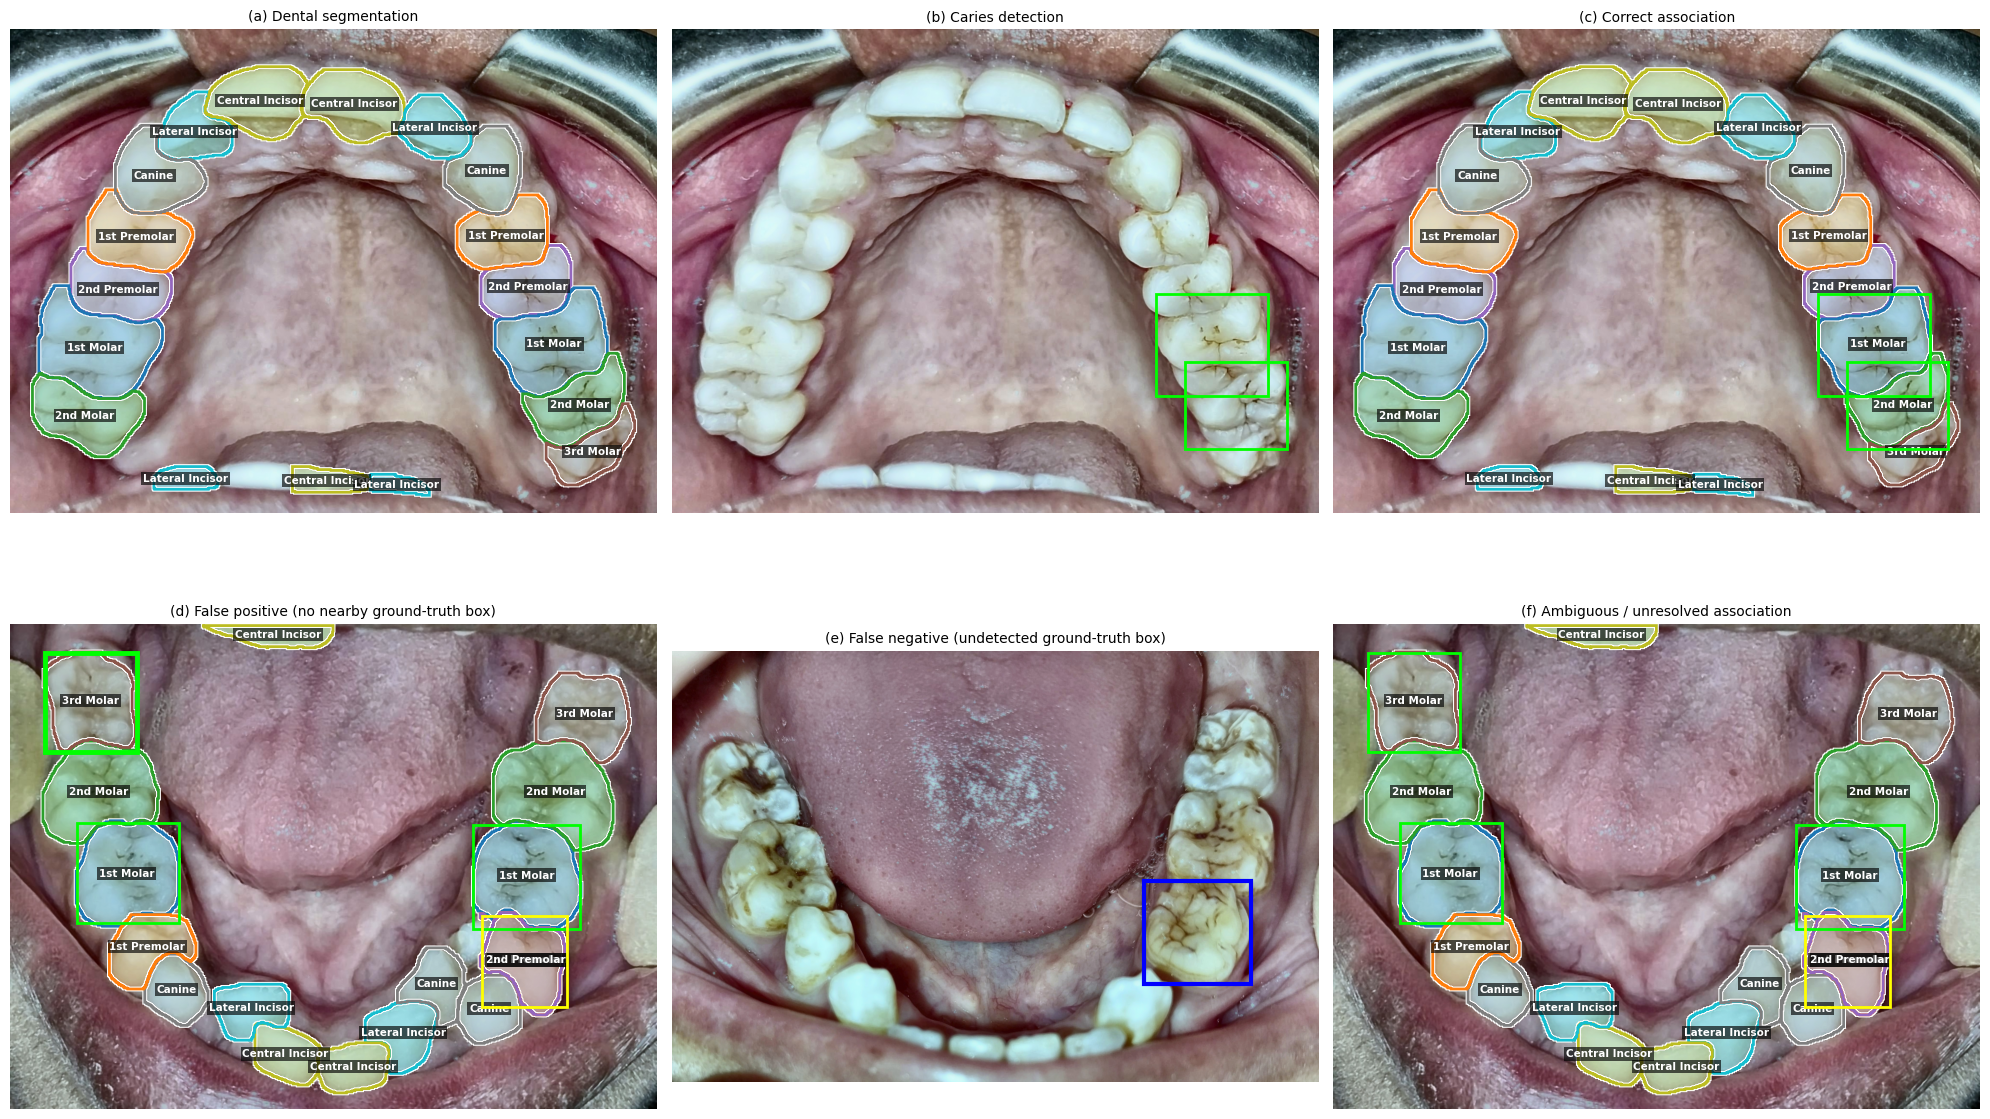

Figure saved to: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/figura_pipeline_integrado_seis_paneles_EN.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
import random


def load_gt_yolo(label_path, w, h):
    boxes_gt = []
    if not label_path.exists():
        return boxes_gt
    text = label_path.read_text().strip()
    if not text:
        return boxes_gt
    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        x1 = (xc - bw / 2) * w
        x2 = (xc + bw / 2) * w
        y1 = (yc - bh / 2) * h
        y2 = (yc + bh / 2) * h
        boxes_gt.append((x1, y1, x2, y2))
    return boxes_gt


def iou(b1, b2):
    xa, ya = max(b1[0], b2[0]), max(b1[1], b2[1])
    xb, yb = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0


MIN_CONF_FIGURE = 0.45
# NOTE: this higher confidence threshold (0.45) is used only for figure clarity/readability and is NOT the operating point used for
# Table 15/16/17 metrics (conf=0.25).

def filter_by_confidence(boxes, instances, min_conf=MIN_CONF_FIGURE):
    boxes_f = [c for c in boxes if c['conf'] >= min_conf]
    instances_f = [i for i in instances if i['conf'] >= min_conf]
    return boxes_f, instances_f


INTRAORAL_KEYWORDS = ['occlusal', 'oclusal', 'mandibular', 'maxillary']


def is_intraoral(path):
    name = path.name.lower()
    return any(p in name for p in INTRAORAL_KEYWORDS)


def draw_panel(ax, image_path, boxes, instances, results, highlight_idx=None, title="",
               show_names=True, mask_alpha=0.25, contour_width=2):
    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    colors = plt.cm.tab10(np.linspace(0, 1, len(NOMBRES_DIENTES)))

    ax.imshow(img)

    for inst in instances:
        color_rgb = colors[NOMBRES_DIENTES.index(inst['clase'])][:3]

        mask_rgba = np.zeros((*inst['mask'].shape, 4))
        mask_rgba[inst['mask']] = (*color_rgb, mask_alpha)
        ax.imshow(mask_rgba)

        contours, _ = cv2.findContours(inst['mask'].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            c = c.squeeze()
            if c.ndim == 2 and len(c) > 2:
                polygon = patches.Polygon(
                    c, closed=True, fill=False,
                    edgecolor='white', linewidth=contour_width + 1.5, zorder=3
                )
                ax.add_patch(polygon)

                polygon2 = patches.Polygon(
                    c, closed=True, fill=False,
                    edgecolor=tuple(color_rgb), linewidth=contour_width, zorder=4
                )
                ax.add_patch(polygon2)

        if show_names:
            ys, xs = np.where(inst['mask'])
            if len(xs) > 0:
                cx, cy = int(xs.mean()), int(ys.mean())
                ax.text(
                    cx, cy, inst['clase'],
                    color='white', fontsize=7.5, fontweight='bold',
                    ha='center', va='center', zorder=5,
                    bbox=dict(facecolor='black', alpha=0.65, pad=1.2, edgecolor='none')
                )

    for j, (box, r) in enumerate(zip(boxes, results)):
        x1, y1, x2, y2 = box['bbox']
        color = {'asociada': 'lime', 'no_asociada': 'red', 'ambigua': 'yellow'}[r['estado']]
        lw = 3.5 if j == highlight_idx else 2
        ax.add_patch(
            patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=lw, edgecolor=color, facecolor='none', zorder=6
            )
        )

    ax.set_title(title, fontsize=10)
    ax.axis('off')


# --- 1) Imagen fija para los paneles a), b), c) ---
CHOSEN_IMAGE_NAME = "retractors_Maxillary_Occlusal_anonymous_003-008-596-01_1729002084186_Maxillary_Occlusal_View.jpg"

chosen_path = next(r for r in IMG_PRUEBA if r.name == CHOSEN_IMAGE_NAME)
boxes, instances, shape = cache_prueba.get(chosen_path.name, inferir_par(chosen_path))
boxes, instances = filter_by_confidence(boxes, instances)
results = asociar_detecciones(boxes, instances, shape, TAU_FINAL, DELTA_FINAL)
example_associated = (chosen_path, boxes, instances, shape, results)


# --- 2) Caso ambiguo: automático ---
example_ambiguous = None
for ruta in IMG_PRUEBA:
    boxes_a, instances_a, shape_a = cache_prueba.get(ruta.name, inferir_par(ruta))
    boxes_a, instances_a = filter_by_confidence(boxes_a, instances_a)
    if not boxes_a or not instances_a:
        continue
    results_a = asociar_detecciones(boxes_a, instances_a, shape_a, TAU_FINAL, DELTA_FINAL)
    if 'ambigua' in [r['estado'] for r in results_a]:
        example_ambiguous = (ruta, boxes_a, instances_a, shape_a, results_a)
        break


# --- 3) Falso positivo: otra imagen, preferiblemente intraoral ---
SEED_FP = 42
random.seed(SEED_FP)

fp_candidates_intraoral = []
fp_candidates_other = []

for ruta in IMG_PRUEBA:
    if ruta.name == CHOSEN_IMAGE_NAME:
        continue

    boxes, instances, shape = cache_prueba.get(ruta.name, inferir_par(ruta))
    boxes, instances = filter_by_confidence(boxes, instances)
    if not boxes:
        continue

    label_path = LBL_PRUEBA / (ruta.stem + ".txt")
    gt = load_gt_yolo(label_path, shape[1], shape[0])
    results = asociar_detecciones(boxes, instances, shape, TAU_FINAL, DELTA_FINAL)

    for j, box in enumerate(boxes):
        best_iou = max([iou(box['bbox'], g) for g in gt], default=0)
        if best_iou < 0.1:
            candidate = (ruta, boxes, instances, shape, results, j)
            if is_intraoral(ruta):
                fp_candidates_intraoral.append(candidate)
            else:
                fp_candidates_other.append(candidate)

fp_pool = fp_candidates_intraoral if fp_candidates_intraoral else fp_candidates_other

if fp_pool:
    example_false_positive = random.choice(fp_pool)
    print(f"False positive chosen: {example_false_positive[0].name} | box_idx={example_false_positive[5]}")
else:
    example_false_positive = None
    print("No clear false positive found.")


# --- 4) Falso negativo: automático ---
example_false_negative = None
for ruta in IMG_PRUEBA:
    boxes, instances, shape = cache_prueba.get(ruta.name, inferir_par(ruta))
    boxes, instances = filter_by_confidence(boxes, instances)
    label_path = LBL_PRUEBA / (ruta.stem + ".txt")
    gt = load_gt_yolo(label_path, shape[1], shape[0])
    predicted = [c['bbox'] for c in boxes]
    missed = [g for g in gt if max([iou(g, p) for p in predicted], default=0) < 0.1]
    if missed:
        example_false_negative = (ruta, missed)
        break


# --- 5) Construir la figura ---
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

if example_associated:
    ruta, boxes, instances, shape, results = example_associated
    draw_panel(axes[0, 0], ruta, [], instances, [], title="(a) Dental segmentation", show_names=True)
    draw_panel(axes[0, 1], ruta, boxes, [], results, title="(b) Caries detection", show_names=False)
    draw_panel(axes[0, 2], ruta, boxes, instances, results, title="(c) Correct association", show_names=True)
else:
    for ax in axes[0]:
        ax.axis('off')
        ax.set_title("No example available", fontsize=10)

if example_false_positive:
    ruta, boxes, instances, shape, results, j_fp = example_false_positive
    draw_panel(
        axes[1, 0], ruta, boxes, instances, results, highlight_idx=j_fp,
        title="(d) False positive (no nearby ground-truth box)", show_names=True
    )
else:
    axes[1, 0].axis('off')
    axes[1, 0].set_title("No clear false positive found", fontsize=10)

if example_false_negative:
    ruta, missed = example_false_negative
    img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
    axes[1, 1].imshow(img)
    for (x1, y1, x2, y2) in missed:
        axes[1, 1].add_patch(
            patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=3, edgecolor='blue', facecolor='none'
            )
        )
    axes[1, 1].set_title("(e) False negative (undetected ground-truth box)", fontsize=10)
    axes[1, 1].axis('off')
else:
    axes[1, 1].axis('off')
    axes[1, 1].set_title("No clear false negative found", fontsize=10)

if example_ambiguous:
    ruta, boxes, instances, shape, results = example_ambiguous
    draw_panel(
        axes[1, 2], ruta, boxes, instances, results,
        title="(f) Ambiguous / unresolved association", show_names=True
    )
else:
    axes[1, 2].axis('off')
    axes[1, 2].set_title("No example available", fontsize=10)

plt.tight_layout()
FIGURE_PANELS_PATH = DATASET_CARIES.parent / "figura_pipeline_integrado_seis_paneles_EN.png"
plt.savefig(FIGURE_PANELS_PATH, dpi=200)
plt.show()
print(f"Figure saved to: {FIGURE_PANELS_PATH}")

In [ ]:
# Listar imágenes intraorales disponibles en el conjunto de prueba, con su cantidad de instancias detectadas
candidatas = []
for ruta in IMG_PRUEBA:
    if not is_intraoral(ruta):
        continue
    cajas, instancias, shape = cache_prueba.get(ruta.name, inferir_par(ruta))
    cajas, instancias = filter_by_confidence(cajas, instancias)
    candidatas.append((ruta.name, len(instancias), len(cajas)))

candidatas.sort(key=lambda x: -x[1])  # las que más dientes detectaron primero
for nombre, n_inst, n_cajas in candidatas[:25]:
    print(f"{n_inst:2d} dientes | {n_cajas} caja(s) caries | {nombre}")

26 dientes | 4 caja(s) caries | retractors_Mandibular_anonymous_003_103_357_01_1728053115007_Mandibular_View.jpg
23 dientes | 4 caja(s) caries | retractors_Mandibular_anonymous_003-008-678-01_1729248899061_Mandibular_View.jpg
23 dientes | 4 caja(s) caries | retractors_Mandibular_anonymous_003_103_414_01_1728387955658_Mandibular_View.jpg
22 dientes | 4 caja(s) caries | pilot_Mandibular_anonymous-mandibularView-1727261519140.jpg
22 dientes | 4 caja(s) caries | retractors_Mandibular_anonymous_003-008-596-01_1729002084186_Mandibular_View.jpg
22 dientes | 2 caja(s) caries | retractors_Mandibular_anonymous_003-008-684-01_1729257374840_Mandibular_View.jpg
21 dientes | 4 caja(s) caries | no_retractors_Mandibular_anonymous_003_103_298_00_1727864717921_Mandibular_View.jpg
21 dientes | 4 caja(s) caries | pilot_Mandibular_anonymous-mandibularView-1727865092793.jpg
21 dientes | 1 caja(s) caries | retractors_Mandibular_anonymous_003-007-676-01_1729246273597_Mandibular_View.jpg
21 dientes | 0 caja(s)

**Note:** Panels d) and e) are automatically selected from “unassociated” cases; it is advisable to review them manually and, if they do not correspond exactly to a false positive from the detector or a false negative relative to the reference, replace them with manually curated examples—the automatic criterion only provides an approximate match.

## CELL 12 — Final summary to include in the article

In [ ]:
print("="*70)
print("RESUMEN PARA EL ARTÍCULO")
print("="*70)
print(f"τ (umbral de solapamiento) = {TAU_FINAL}")
print(f"δ (margen de ambigüedad)   = {DELTA_FINAL}")
print(f"Exactitud de asociación    = {exactitud_final:.4f}")
print(f"Cobertura de asociación    = {cobertura_final:.4f}")
print(f"Detecciones evaluadas (prueba) = {n_detecciones}")

# Extract media_pipeline and sd_pipeline from tabla15
media_pipeline = tabla15[tabla15['Componente'] == 'Pipeline integrado']['Media (ms)'].iloc[0]
sd_pipeline = tabla15[tabla15['Componente'] == 'Pipeline integrado']['SD (ms)'].iloc[0]

print(f"Tiempo pipeline integrado  = {media_pipeline:.2f} ± {sd_pipeline:.2f} ms/img")
print("\nArchivos generados en Drive:")
for p in [RUTA_CSV_CALIBRACION, RUTA_GRID, RUTA_CSV_PRUEBA, RUTA_TABLA16,
          RUTA_TABLA17, RUTA_TABLA15, FIGURE_PANELS_PATH]:
    print(" -", p)

RESUMEN PARA EL ARTÍCULO
τ (umbral de solapamiento) = 0.1
δ (margen de ambigüedad)   = 0.02
Exactitud de asociación    = 0.9687
Cobertura de asociación    = 0.9858
Detecciones evaluadas (prueba) = 777
Tiempo pipeline integrado  = 109.27 ± 42.86 ms/img

Archivos generados en Drive:
 - /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/calibracion_asociacion_geometrica.csv
 - /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/grid_tau_delta.csv
 - /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/referencia_asociacion_prueba.csv
 - /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/tabla16_asociacion_geometrica_global.csv
 - /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/tabla17_asociacion_geometrica_por_categoria.csv
 - /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/tabla15_tiempos_pipeline_integrado.csv
 - /content/drive/MyDrive/UNIVERSIDAD/

In [ ]:
import numpy as np

def bootstrap_exactitud_cobertura(df, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(df)
    exactitudes, coberturas = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        muestra = df.iloc[idx]
        asociadas = muestra[muestra['estado'] == 'asociada']
        correctas = asociadas['correcta'].sum()
        total_asociadas = len(asociadas)
        exactitudes.append(correctas / total_asociadas if total_asociadas > 0 else np.nan)
        coberturas.append(total_asociadas / len(muestra))
    exactitudes = np.array(exactitudes)
    coberturas = np.array(coberturas)
    return {
        "exactitud_media": np.nanmean(exactitudes),
        "exactitud_ic95": np.nanpercentile(exactitudes, [2.5, 97.5]),
        "cobertura_media": np.mean(coberturas),
        "cobertura_ic95": np.percentile(coberturas, [2.5, 97.5]),
    }

resultado = bootstrap_exactitud_cobertura(df_resultados_prueba)
print(resultado)


{'exactitud_media': np.float64(0.9687750449671994), 'exactitud_ic95': array([    0.95675,     0.98047]), 'cobertura_media': np.float64(0.9859118404118404), 'cobertura_ic95': array([    0.97683,     0.99356])}
